# Clustering de Cryptomonnaies Basé sur les Prix de Clôture

Ce notebook réalise un clustering non supervisé sur les séries temporelles quotidiennes des prix de clôture d’un ensemble de cryptomonnaies. Les données proviennent de l’onglet Close. Comme certaines cryptomonnaies ont commencé à être cotées plus tard que d’autres, certaines séries présentent des valeurs manquantes au début. Notre approche suit les étapes de pré-traitement couramment recommandées dans la littérature sur le clustering de séries temporelles :

- **Impute missing values** via interpolation, une technique permettant d’estimer les valeurs manquantes à partir des points voisins plutôt que d’utiliser une simple moyenne ou médiane.
- **Standardize** chaque série temporelle avant le clustering. Sans standardisation, les variables présentant une variation plus importante dominent la distance euclidienne utilisée par k-means. 
- **Use k‑means clustering** pour regrouper les cryptomonnaies présentant des dynamiques de prix similaires. Le clustering de séries temporelles utilise souvent des transformations telles que la standardisation et l’interpolation afin de réduire le bruit avant d’appliquer les algorithmes de clustering.

Nous déterminerons un nombre approprié de clusters en calculant le score de silhouette pour une plage de valeurs de k et en choisissant le k qui maximise ce score.


In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


## Charger les données de prix de clôture


La feuille brute des prix de clôture contient deux lignes d’en-tête. La deuxième ligne d’en-tête (index 2) contient les tickers. Nous lisons donc la feuille avec `header=2`, nous renommons la première colonne en `Date` et nous la convertissons en type `datetime`. Ensuite, nous convertissons chaque colonne en valeurs numériques et traitons les valeurs manquantes avec une interpolation linéaire, puis un remplissage avant (forward fill) et arrière (backward fill). Les colonnes ne contenant aucune donnée ou uniquement des valeurs constantes sont supprimées.


In [9]:
# Importation and Initial Preprocessing
file_path = 'crypto.xlsx'
df = pd.read_excel(file_path, sheet_name='Close', header=2)

df = df.rename(columns={'Unnamed: 0': 'Date'})

df['Date'] = pd.to_datetime(df['Date'])

crypto_cols = df.columns[1:]


#Conversion dus prix en numérique et imputation des valeurs manquantes
for col in crypto_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].interpolate(method='linear', limit_direction='both')
    df[col] = df[col].ffill().bfill()

# Enlever les colonnes qui sont entièrement NaN ou constantes
cols_to_drop = []
for col in crypto_cols:
    if df[col].isna().all() or df[col].nunique() <= 1:
        cols_to_drop.append(col)

df = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")

crypto_cols = df.columns[1:]

print(f"Data shape after preprocessing: {df.shape}")
df.head(3)


Dropped columns: ['XFTUSD Curncy']
Data shape after preprocessing: (1992, 49)


,Date,XUTUSD Curncy,XICUSD Curncy,XFLUSD Curncy,XSTUSD Curncy,XINUSD Curncy,XFIUSD Curncy,XAVUSD Curncy,XTKUSD Curncy,XSAUSD Curncy,...,XIOUSD Curncy,XLMUSD Curncy,XETUSD Curncy,XDTUSD Curncy,XMRUSD Curncy,XDHUSD Curncy,XDGUSD Curncy,XRPUSD Curncy,XLCUSD Curncy,XBTUSD Curncy
0,2019-12-31,0.0511,36.7938,12.9582,0.9013,4.1797,178.6152,15.1048,2.2789,0.2848,...,0.2320,0.0451,128.415,1.0017,44.813,41.235,0.0645,0.1906,41.275,7158.27
1,2020-01-01,0.0511,36.7938,12.9582,0.9013,4.1797,178.6152,15.1048,2.2789,0.2848,...,0.2440,0.0452,131.790,1.0026,45.807,42.768,0.0645,0.1935,41.725,7216.21
2,2020-01-02,0.0511,36.7938,12.9582,0.9013,4.1797,178.6152,15.1048,2.2789,0.2848,...,0.2495,0.0438,127.911,0.9970,44.830,40.346,0.0645,0.1873,39.747,6960.58


## Préparation des données pour le clustering


La série temporelle de chaque cryptomonnaie est organisée en lignes afin de pouvoir les regrouper selon leurs profils d’évolution dans le temps.
Nous standardisons chaque série individuellement (soustraction de sa moyenne puis division par son écart-type) afin d’éliminer les différences d’échelle.

Après la standardisation, nous calculons le score de silhouette pour plusieurs valeurs possibles du nombre de clusters, afin de choisir un `k` approprié.


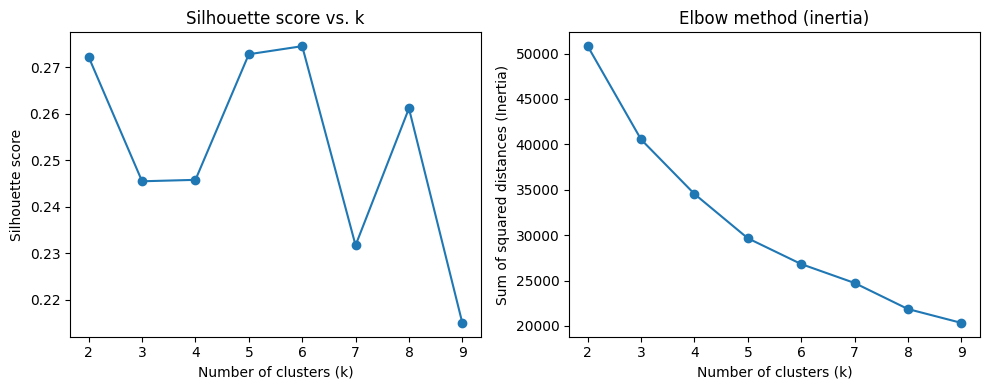

Optimal number of clusters: 6


,Crypto,Cluster
0,XDIUSD Curncy,0
1,XUCUSD Curncy,0
2,XSAUSD Curncy,1
3,XAVUSD Curncy,1
4,XEGUSD Curncy,1
5,XCRUSD Curncy,1
6,XLUUSD Curncy,1
7,XINUSD Curncy,1
8,XFMUSD Curncy,1
9,XMNUSD Curncy,1


In [10]:
X = df[crypto_cols].T
X_standardized = (X - X.mean(axis=1).values.reshape(-1, 1)) / X.std(axis=1).values.reshape(-1, 1)
X_standardized = X_standardized.fillna(0)

#Determiner le nombre optimal de clusters en utilisant le score de silhouette
ks = range(2, 10)
silhouette_scores = []
inertias = []
for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_standardized)
    sil_score = silhouette_score(X_standardized, labels)
    silhouette_scores.append(sil_score)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(list(ks), silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score vs. k')

plt.subplot(1,2,2)
plt.plot(list(ks), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of squared distances (Inertia)')
plt.title('Elbow method (inertia)')
plt.tight_layout()
plt.show()

optimal_k = ks[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")


kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_standardized)

cluster_results = pd.DataFrame({'Crypto': X_standardized.index, 'Cluster': cluster_labels})
cluster_results = cluster_results.sort_values('Cluster').reset_index(drop=True)
cluster_results


## Visualiser les clusters en 2D

Pour mieux comprendre la manière dont les cryptomonnaies sont regroupées, nous réduisons la dimensionnalité des données standardisées à l’aide de l’analyse en composantes principales (PCA).
Nous traçons ensuite les deux premières composantes principales et colorons les points selon leur cluster d’appartenance.

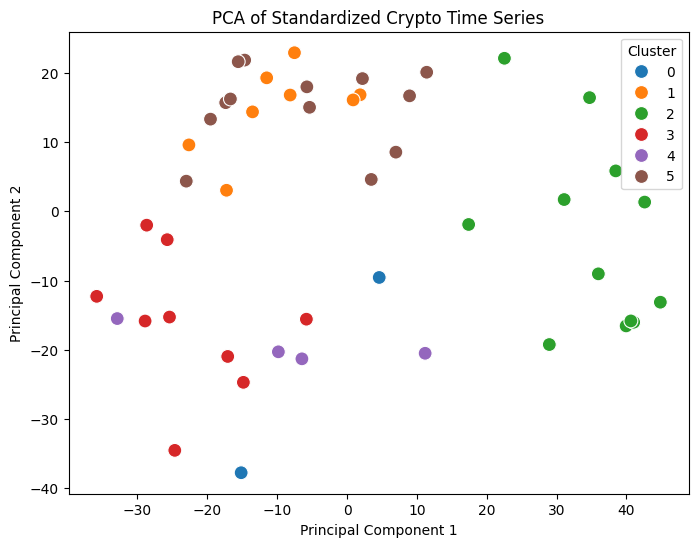

In [11]:
# Reduce to 2 dimensions for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standardized)

# Plot the PCA results with cluster labels
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette='tab10', s=100)
plt.title('PCA of Standardized Crypto Time Series')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


Ce graphique montre la projection des cryptomonnaies dans un espace à deux dimensions obtenu grâce au PCA ; chaque point représente une crypto standardisée, et les couleurs indiquent les clusters k-means. Les cryptos proches sur le graphique ont des évolutions de prix similaires, tandis que celles éloignées appartiennent à des dynamiques de marché différentes.

La formation de six clusters reflète le fait que certaines cryptomonnaies ont évolué de manière très similaire au fil du temps : par exemple, le cluster 2 regroupe de grands actifs comme Bitcoin, XRP ou Dogecoin, dont les cycles haussiers et baissiers ont été largement synchronisés dans le marché crypto, tandis que le cluster 1 rassemble des cryptos plus "secondaires" dont la dynamique est plus lente et moins volatile. À l’inverse, les clusters 3, 4 et 5 concentrent des actifs plus spéculatifs ou moins corrélés, caractérisés par des mouvements de prix plus irréguliers, des phases de stagnation ou des épisodes de forte volatilité